In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [3]:
target_species = 4
species_threshold = 0.2

rolling_species_count = rd.Expr.select("species.count").rolling(25).mean()
err = rd.Expr.select("species.count").error(target_species) * 0.01

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [4]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(
        rd.Dist.neat(),
        species_threshold=species_threshold,
        target_species=target_species,
    )
    .metrics(species_rolling=rolling_species_count, error=err)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-06-10T21:49:01.294087Z  INFO Epoch 1    | Score:   2.0038 | Time: 1.57ms
2026-06-10T21:49:01.294435Z  INFO Epoch 2    | Score:   1.6821 | Time: 1.80ms
2026-06-10T21:49:01.294673Z  INFO Epoch 3    | Score:   1.6821 | Time: 2.03ms
2026-06-10T21:49:01.294967Z  INFO Epoch 4    | Score:   1.6821 | Time: 2.31ms
2026-06-10T21:49:01.295097Z  INFO Epoch 5    | Score:   1.6821 | Time: 2.42ms
2026-06-10T21:49:01.295215Z  INFO Epoch 6    | Score:   1.6821 | Time: 2.53ms
2026-06-10T21:49:01.295314Z  INFO Epoch 7    | Score:   1.6821 | Time: 2.62ms
2026-06-10T21:49:01.295423Z  INFO Epoch 8    | Score:   1.6821 | Time: 2.71ms
2026-06-10T21:49:01.295522Z  INFO Epoch 9    | Score:   1.6821 | Time: 2.80ms
2026-06-10T21:49:01.295619Z  INFO Epoch 10   | Score:   1.6821 | Time: 2.88ms
2026-06-10T21:49:01.295714Z  INFO Epoch 11   | Score:   1.6821 | Time: 2.97ms
2026-06-10T21:49:01.295838Z  INFO Epoch 12   | Score:   1.6821 | Time: 3.06ms
2026-06-10T21:49:01.295957Z  INFO Epoch 13   | Score:   1.6821 |

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

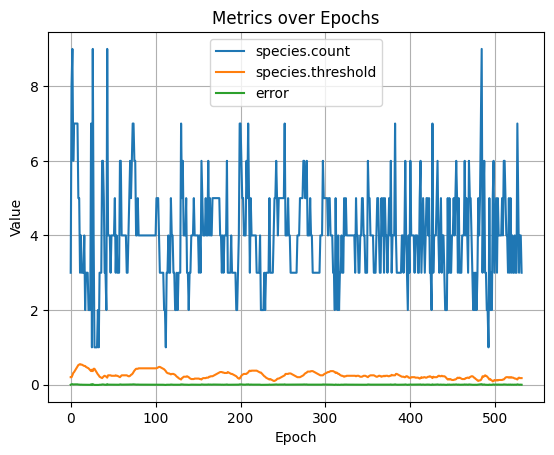

In [5]:
collector.plot(
    "species.count", "species.threshold", "error"
)  # , "species_rolling", "species_count_error", "err")
# collector.plot("err")

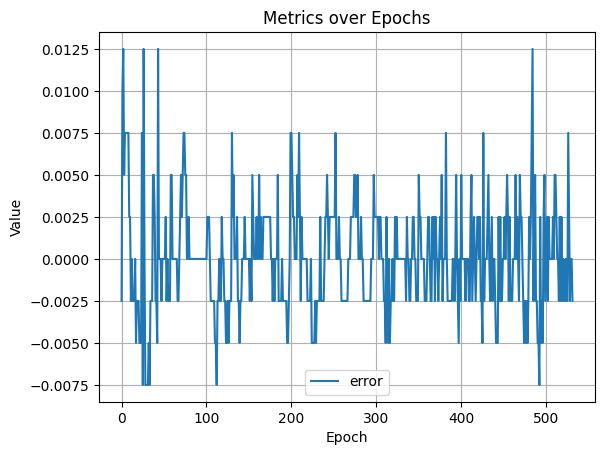

In [6]:
collector.plot("error")

In [7]:
df = collector.to_polars()
df.filter(pl.col("name") == "species.count").tail(20)
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""species.count""",5.0,2051.0,3.998051,1.280105,1.638668,2.825188,1.0,9.0,513,null,null,null,null,null,null,512,1,"[""species"", ""statistic""]"
"""species.count""",4.0,2055.0,3.998055,1.278856,1.635474,2.840932,1.0,9.0,514,null,null,null,null,null,null,513,1,"[""species"", ""statistic""]"
"""species.count""",4.0,2059.0,3.998058,1.277612,1.632292,2.856801,1.0,9.0,515,null,null,null,null,null,null,514,1,"[""species"", ""statistic""]"
"""species.count""",3.0,2062.0,3.996124,1.277127,1.631053,2.874819,1.0,9.0,516,null,null,null,null,null,null,515,1,"[""species"", ""statistic""]"
"""species.count""",5.0,2067.0,3.998066,1.276652,1.629841,2.862249,1.0,9.0,517,null,null,null,null,null,null,516,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""species.count""",5.0,2110.0,3.996212,1.275958,1.628069,2.92118,1.0,9.0,528,null,null,null,null,null,null,527,1,"[""species"", ""statistic""]"
"""species.count""",3.0,2113.0,3.994329,1.275485,1.626862,2.938951,1.0,9.0,529,null,null,null,null,null,null,528,1,"[""species"", ""statistic""]"
"""species.count""",4.0,2117.0,3.99434,1.274279,1.623786,2.955012,1.0,9.0,530,null,null,null,null,null,null,529,1,"[""species"", ""statistic""]"


In [8]:
df.filter(pl.col("name") == "error").tail(20)

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""error""",0.0025,-0.0025,-0.000005,0.0032,0.00001,0.0,-0.0075,0.0125,513,null,null,null,null,null,null,512,1,"[""statistic"", ""expr""]"
"""error""",0.0,-0.0025,-0.000005,0.003197,0.00001,0.0,-0.0075,0.0125,514,null,null,null,null,null,null,513,1,"[""statistic"", ""expr""]"
"""error""",0.0,-0.0025,-0.000005,0.003194,0.00001,0.0,-0.0075,0.0125,515,null,null,null,null,null,null,514,1,"[""statistic"", ""expr""]"
"""error""",-0.0025,-0.005,-0.00001,0.003193,0.00001,0.0,-0.0075,0.0125,516,null,null,null,null,null,null,515,1,"[""statistic"", ""expr""]"
"""error""",0.0025,-0.0025,-0.000005,0.003192,0.00001,0.0,-0.0075,0.0125,517,null,null,null,null,null,null,516,1,"[""statistic"", ""expr""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""error""",0.0025,-0.005,-0.000009,0.00319,0.00001,0.0,-0.0075,0.0125,528,null,null,null,null,null,null,527,1,"[""statistic"", ""expr""]"
"""error""",-0.0025,-0.0075,-0.000014,0.003189,0.00001,0.0,-0.0075,0.0125,529,null,null,null,null,null,null,528,1,"[""statistic"", ""expr""]"
"""error""",0.0,-0.0075,-0.000014,0.003186,0.00001,0.0,-0.0075,0.0125,530,null,null,null,null,null,null,529,1,"[""statistic"", ""expr""]"


In [9]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

532


531